In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [9]:
df = pd.read_csv('data/prices_round_0_day_-2.csv', sep=';')
# df[df['product'] == 'EMERALDS'][['product', 'mid_price']][:40]

In [19]:
# File maps
price_files = {
    -2: "./data/prices_round_0_day_-2.csv",
    -1: "./data/prices_round_0_day_-1.csv"
}

trade_files = {
    -2: "./data/trades_round_0_day_-2.csv",
    -1: "./data/trades_round_0_day_-1.csv"
}

# Load and offset timestamps by 1M steps
OFFSET = 1_000_000


## EMERALDS
emerald_prices_full = []
emerald_trades_full = []

for i, (day, pf) in enumerate(price_files.items()):
    df = pd.read_csv(pf, sep=';')
    df = df[df['product'] == 'EMERALDS'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    emerald_prices_full.append(df)

for i, (day, tf) in enumerate(trade_files.items()):
    df = pd.read_csv(tf, sep=';')
    df = df[df['symbol'] == 'EMERALDS'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    emerald_trades_full.append(df)

# Combine
emerald_prices = pd.concat(emerald_prices_full, ignore_index=True).sort_values('timestamp')
emerald_trades = pd.concat(emerald_trades_full, ignore_index=True).sort_values('timestamp')


## TOMATOES
tomato_prices_full = []
tomato_trades_full = []

for i, (day, pf) in enumerate(price_files.items()):
    df = pd.read_csv(pf, sep=';')
    df = df[df['product'] == 'TOMATOES'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    tomato_prices_full.append(df)

for i, (day, tf) in enumerate(trade_files.items()):
    df = pd.read_csv(tf, sep=';')
    df = df[df['symbol'] == 'TOMATOES'].copy()
    df['timestamp'] += i * OFFSET
    df['day'] = day
    tomato_trades_full.append(df)

# Combine
tomato_prices = pd.concat(tomato_prices_full, ignore_index=True).sort_values('timestamp')
tomato_trades = pd.concat(tomato_trades_full, ignore_index=True).sort_values('timestamp')

print(len(tomato_prices), len(tomato_trades))
tomato_trades.head(5)

20000 820


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
2,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
3,6700,NaN,NaN,TOMATOES,XIRECS,4988.0,5,-2
4,7100,NaN,NaN,TOMATOES,XIRECS,5000.0,3,-2


# EDA

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# TOMATOES plot
tomatoes_sorted = tomato_prices.sort_values('timestamp')
axes[0].plot(tomatoes_sorted['timestamp'], tomatoes_sorted['mid_price'], marker='o', color='red', linewidth=2)
axes[0].fill_between(tomatoes_sorted['timestamp'], tomatoes_sorted['bid_price_1'], tomatoes_sorted['ask_price_1'], alpha=0.3, color='red')
axes[0].set_ylabel('Price')
axes[0].set_title('TOMATOES - Mid Price Over Time')
axes[0].grid(True)

# EMERALDS plot
emeralds_sorted = emerald_prices.sort_values('timestamp')
axes[1].plot(emeralds_sorted['timestamp'], emeralds_sorted['mid_price'], marker='o', color='green', linewidth=2)
axes[1].fill_between(emeralds_sorted['timestamp'], emeralds_sorted['bid_price_1'], emeralds_sorted['ask_price_1'], alpha=0.3, color='green')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Price')
axes[1].set_title('EMERALDS - Mid Price Over Time')
axes[1].grid(True)

plt.tight_layout()
plt.show()

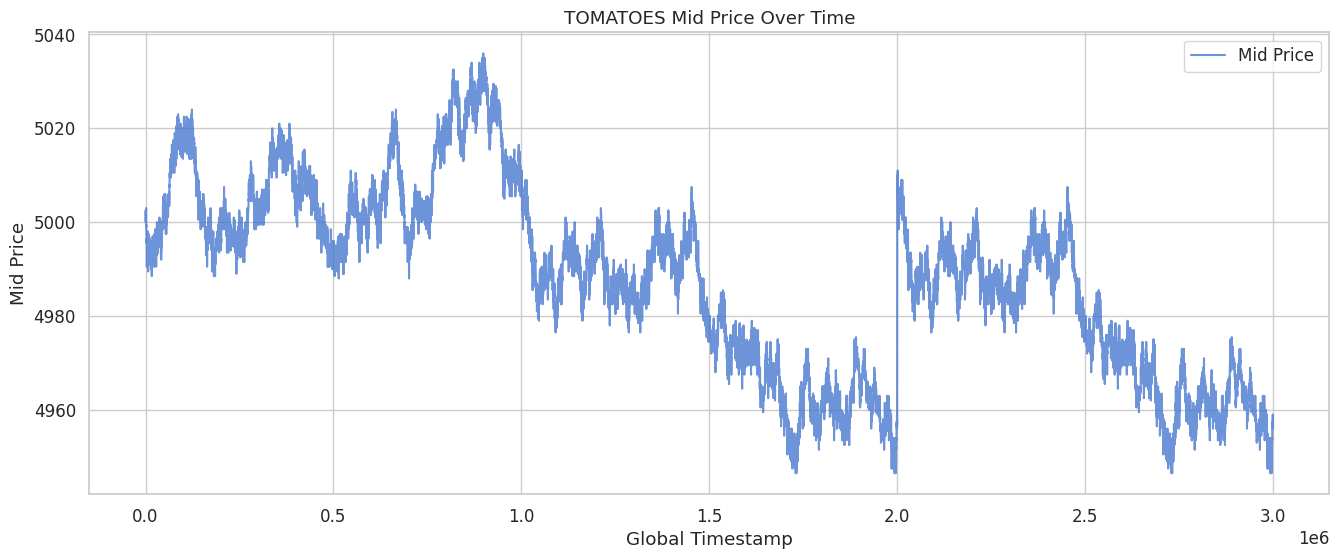

In [15]:
# Mid price over time
tomato_prices['mid_price'] = tomato_prices['mid_price']

plt.figure(figsize=(16, 6))
plt.plot(tomato_prices['timestamp'], tomato_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('TOMATOES Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

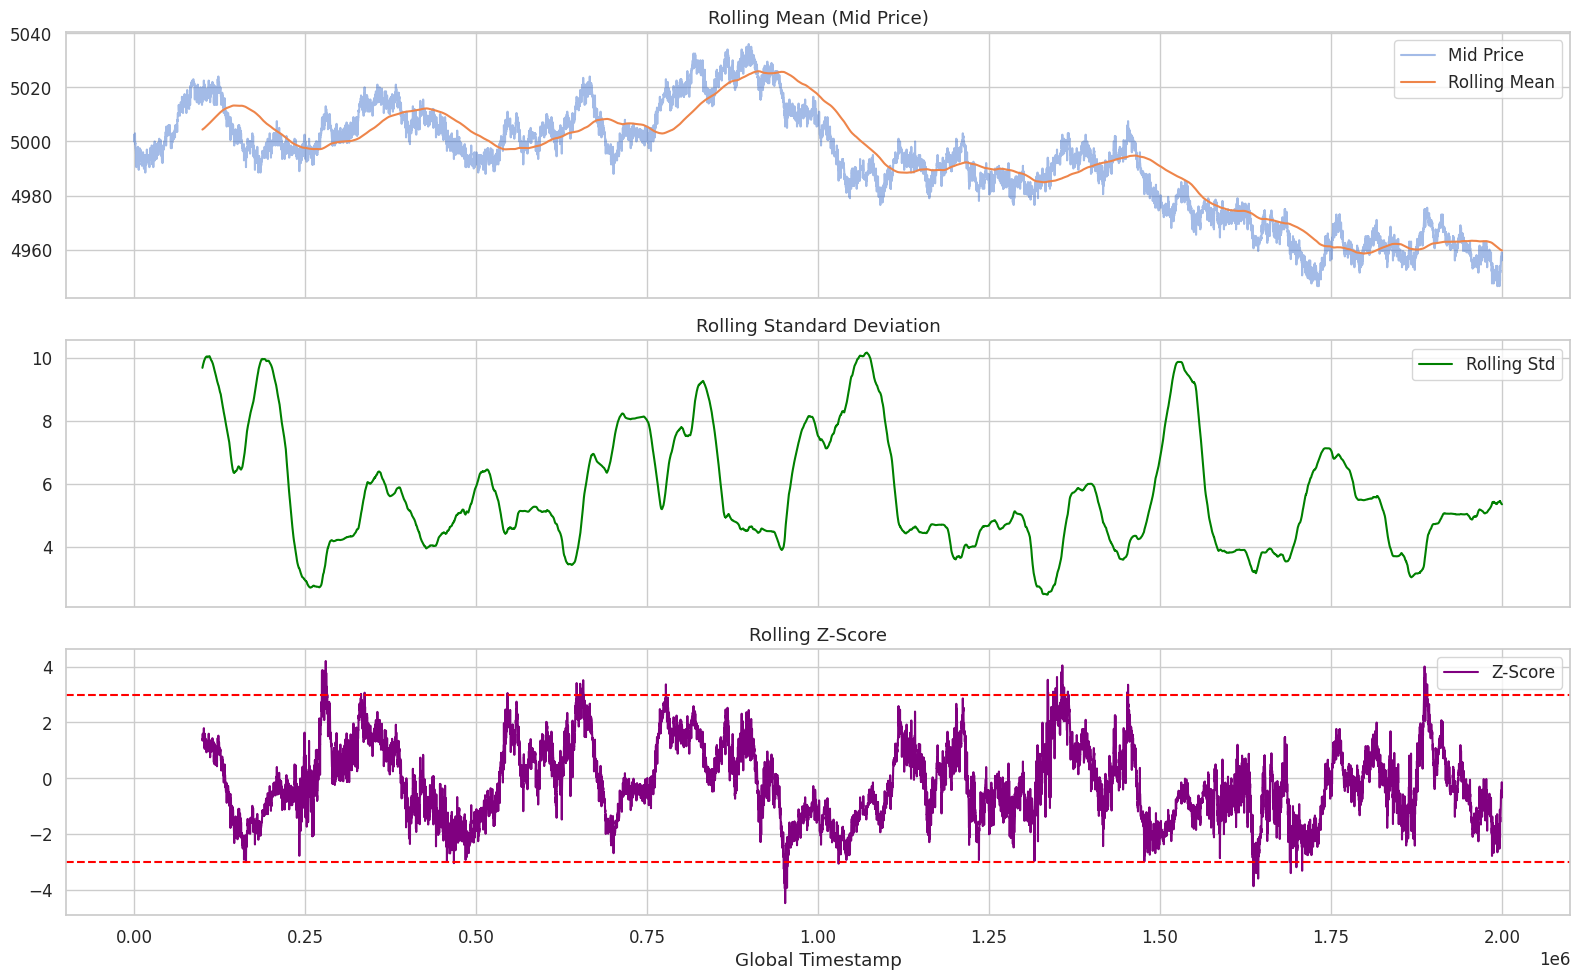

In [24]:
# Rolling stats
WINDOW = 1000
tomato_prices['rolling_mean'] = tomato_prices['mid_price'].rolling(WINDOW).mean()
tomato_prices['rolling_std'] = tomato_prices['mid_price'].rolling(WINDOW).std()
tomato_prices['z_score'] = (tomato_prices['mid_price'] - tomato_prices['rolling_mean']) / tomato_prices['rolling_std']


fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# plot rolling mean, atop of price
axs[0].plot(tomato_prices['timestamp'], tomato_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(tomato_prices['timestamp'], tomato_prices['rolling_mean'], label='Rolling Mean')
axs[0].set_title('Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(tomato_prices['timestamp'], tomato_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(tomato_prices['timestamp'], tomato_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='red', linestyle='--')
axs[2].axhline(-3, color='red', linestyle='--')
axs[2].set_title('Rolling Z-Score')
axs[2].legend()

plt.xlabel('Global Timestamp')
plt.tight_layout()
plt.show()

# TESTS

In [5]:
from datamodel import OrderDepth, UserId, TradingState, Order
from typing import List
import string

class Trader:

    def bid(self):
        return 15
    
    def run(self, state: TradingState):
        """Only method required. It takes all buy and sell orders for all
        symbols as an input, and outputs a list of orders to be sent."""

        print("traderData: " + state.traderData)
        print("Observations: " + str(state.observations))

        # Orders to be placed on exchange matching engine
        result = {}
        for product in state.order_depths:
            order_depth: OrderDepth = state.order_depths[product]
            orders: List[Order] = []
            acceptable_price = 10  # Participant should calculate this value
            print("Acceptable price : " + str(acceptable_price))
            print("Buy Order depth : " + str(len(order_depth.buy_orders)) + ", Sell order depth : " + str(len(order_depth.sell_orders)))
    
            if len(order_depth.sell_orders) != 0:
                best_ask, best_ask_amount = list(order_depth.sell_orders.items())[0]
                if int(best_ask) < acceptable_price:
                    print("BUY", str(-best_ask_amount) + "x", best_ask)
                    orders.append(Order(product, best_ask, -best_ask_amount))
    
            if len(order_depth.buy_orders) != 0:
                best_bid, best_bid_amount = list(order_depth.buy_orders.items())[0]
                if int(best_bid) > acceptable_price:
                    print("SELL", str(best_bid_amount) + "x", best_bid)
                    orders.append(Order(product, best_bid, -best_bid_amount))
            
            result[product] = orders
    
        traderData = ""  # No state needed - we check position directly
        conversions = 0
        return result, conversions, traderData

In [11]:
from datamodel import Listing, OrderDepth, Trade, TradingState, Observation

timestamp = 1000

listings = {
    "PRODUCT1": Listing(
        symbol="PRODUCT1", 
        product="PRODUCT1", 
        denomination="XIRECS"
    ),
    "PRODUCT2": Listing(
        symbol="PRODUCT2", 
        product="PRODUCT2", 
        denomination="XIRECS"
    ),
}

# Create OrderDepth instances first, then set their dictionaries
order_depths = {
    "PRODUCT1": OrderDepth(),
    "PRODUCT2": OrderDepth(),
}

# Set buy and sell orders
order_depths["PRODUCT1"].buy_orders = {10: 7, 9: 5}
order_depths["PRODUCT1"].sell_orders = {11: -4, 12: -8}
order_depths["PRODUCT2"].buy_orders = {142: 3, 141: 5}
order_depths["PRODUCT2"].sell_orders = {144: -5, 145: -8}

own_trades = {
    "PRODUCT1": [],
    "PRODUCT2": []
}

market_trades = {
    "PRODUCT1": [
        Trade(
            symbol="PRODUCT1",
            price=11,
            quantity=4,
            buyer="",
            seller="",
            timestamp=900
        )
    ],
    "PRODUCT2": []
}

position = {
    "PRODUCT1": 3,
    "PRODUCT2": -5
}

observations = Observation(
    plainValueObservations={},
    conversionObservations={}
)

traderData = ""

# Create TradingState
state = TradingState(
    traderData=traderData,
    timestamp=timestamp,
    listings=listings,
    order_depths=order_depths,
    own_trades=own_trades,
    market_trades=market_trades,
    position=position,
    observations=observations
)

print("TradingState created successfully!")
print(f"Timestamp: {state.timestamp}")
print(f"Products: {list(state.order_depths.keys())}")
print(f"Position: {state.position}")

TradingState created successfully!
Timestamp: 1000
Products: ['PRODUCT1', 'PRODUCT2']
Position: {'PRODUCT1': 3, 'PRODUCT2': -5}


In [49]:
state.order_depths["PRODUCT1"].buy_orders
for price, qty in state.order_depths["PRODUCT1"].buy_orders.items():
    print(f"Price: {price}, Quantity: {qty}")

list(state.order_depths["PRODUCT1"].buy_orders.items())

Price: 10, Quantity: 7
Price: 9, Quantity: 5


[(10, 7), (9, 5)]

0

In [46]:
for product, obj in state.order_depths.items():
    print(f"Product: {product}")
    print(f"Buy Orders: {obj.buy_orders}")
    print(f"Sell Orders: {obj.sell_orders}")

Product: PRODUCT1
Buy Orders: {10: 7, 9: 5}
Sell Orders: {11: -4, 12: -8}
Product: PRODUCT2
Buy Orders: {142: 3, 141: 5}
Sell Orders: {144: -5, 145: -8}


In [27]:
# Test the Trader
trader = Trader()
result, conversions, traderData = trader.run(state)

print("\n=== Trader Results ===")
print(f"Conversions: {conversions}")
print(f"Trader Data: {traderData}")
print("\nOrders returned:")
for product, orders in result.items():
    print(f"  {product}: {orders}")

traderData: 
Observations: (plainValueObservations: {}, conversionObservations: {})
Acceptable price : 10
Buy Order depth : 2, Sell order depth : 2
Acceptable price : 10
Buy Order depth : 2, Sell order depth : 2
SELL 3x 142

=== Trader Results ===
Conversions: 0
Trader Data: 

Orders returned:
  PRODUCT1: []
  PRODUCT2: [(PRODUCT2, 142, -3)]


In [28]:
state.traderData

''